# Fingerspelling Letter Classifier

# Author: Amer Wahid

# Introduction

A real-time captioning tool for American Sign Language needs a foundational building
block: a model that looks at a single photo of a hand shape and identifies which letter
of the alphabet it represents. This notebook builds that first version — a CNN trained
from scratch on the Sign Language MNIST dataset.

The dataset covers 24 classes (A–Z, excluding J and Z, since both require motion and
can't be captured in a still photo). Images are 28x28 grayscale hand-sign photos, stored
as flattened pixel rows.

This notebook covers: exploring the data, preparing it for training, designing and
training a CNN from scratch, evaluating it with per-class metrics (not just overall
accuracy), and diagnosing where and why the model struggles.

# Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

np.random.seed(42)
tf.random.set_seed(42)

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



/kaggle/input/datasets/datamunge/sign-language-mnist/sign_mnist_test.csv
/kaggle/input/datasets/datamunge/sign-language-mnist/amer_sign2.png
/kaggle/input/datasets/datamunge/sign-language-mnist/amer_sign3.png
/kaggle/input/datasets/datamunge/sign-language-mnist/sign_mnist_train.csv
/kaggle/input/datasets/datamunge/sign-language-mnist/american_sign_language.PNG
/kaggle/input/datasets/datamunge/sign-language-mnist/sign_mnist_test/sign_mnist_test.csv
/kaggle/input/datasets/datamunge/sign-language-mnist/sign_mnist_train/sign_mnist_train.csv


# Load Data

In [2]:
DATA_DIR = '/kaggle/input/datasets/datamunge/sign-language-mnist'

train_df = pd.read_csv(f'{DATA_DIR}/sign_mnist_train/sign_mnist_train.csv')
test_df = pd.read_csv(f'{DATA_DIR}/sign_mnist_test/sign_mnist_test.csv')

print(train_df.shape, test_df.shape)
train_df.head()

(27455, 785) (7172, 785)


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


In [3]:
label_to_letter = {i: chr(65 + i) for i in range(26) if i not in [9, 25]}
print(label_to_letter)
print(sorted(train_df['label'].unique()))

{0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E', 5: 'F', 6: 'G', 7: 'H', 8: 'I', 10: 'K', 11: 'L', 12: 'M', 13: 'N', 14: 'O', 15: 'P', 16: 'Q', 17: 'R', 18: 'S', 19: 'T', 20: 'U', 21: 'V', 22: 'W', 23: 'X', 24: 'Y'}
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]


Building the label-to-letter mapping. Labels run 0-25 but skip 9 (J) and 25 (Z), since
both require motion and can't be captured in a still photo. Confirming the training
set's actual label values match this expectation before going further.

# EDA

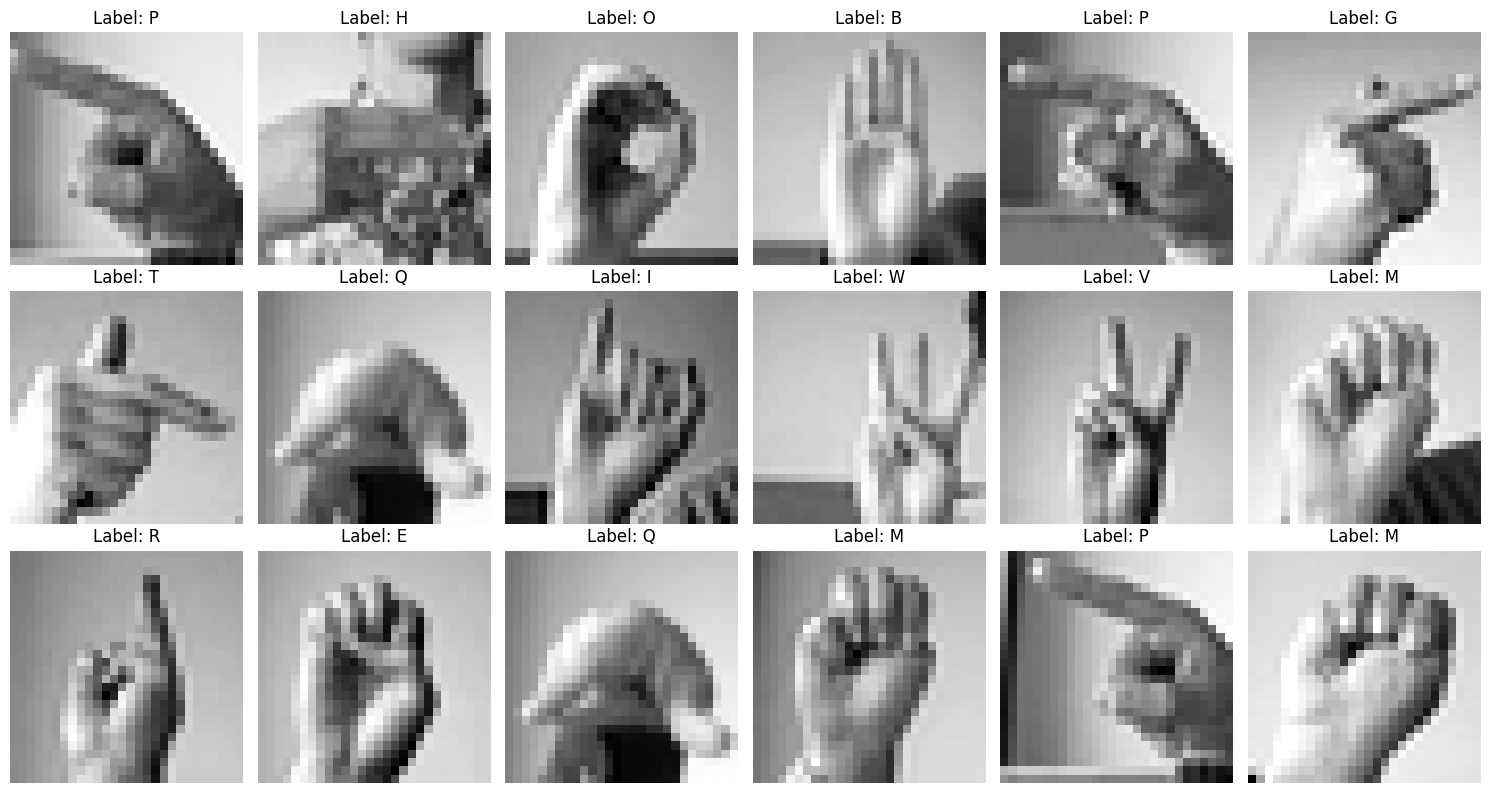

In [4]:
def reshape_to_image(row):
    return row.reshape(28, 28)

X_temp = train_df.drop('label', axis=1).values
y_temp = train_df['label'].values

fig, axes = plt.subplots(3, 6, figsize=(15, 8))
for i, ax in enumerate(axes.flat):
    idx = np.random.randint(0, len(X_temp))
    img = reshape_to_image(X_temp[idx])
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Label: {label_to_letter[y_temp[idx]]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

Reshaping a handful of flattened rows back into 28x28 images to sanity-check that the
data looks like real ASL hand shapes and that labels line up with what's shown.

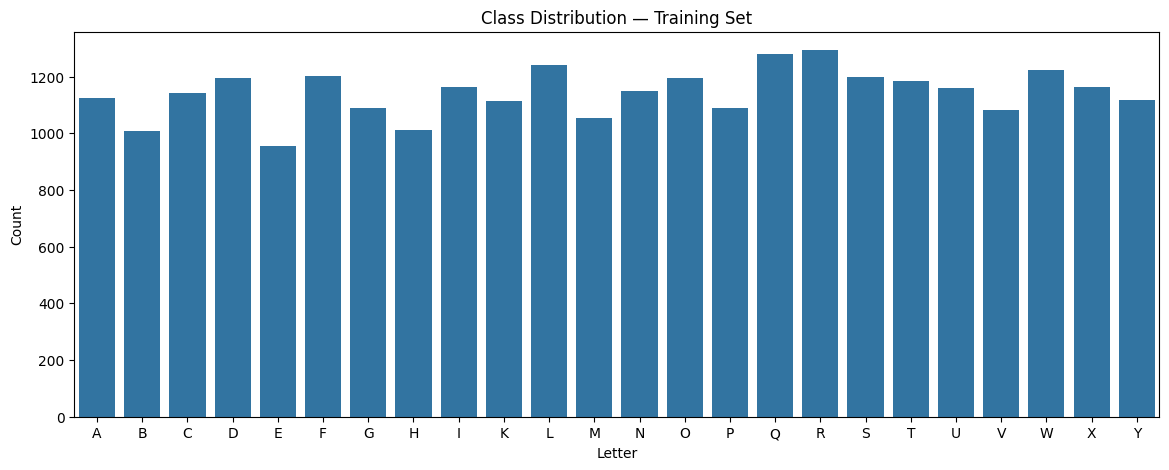

count      24.000000
mean     1143.958333
std        83.758701
min       957.000000
25%      1089.500000
50%      1156.000000
75%      1196.750000
max      1294.000000
Name: count, dtype: float64


In [5]:
plt.figure(figsize=(14, 5))
letter_counts = train_df['label'].map(label_to_letter).value_counts().sort_index()
sns.barplot(x=letter_counts.index, y=letter_counts.values)
plt.title('Class Distribution — Training Set')
plt.xlabel('Letter')
plt.ylabel('Count')
plt.show()

print(letter_counts.describe())

Checking class balance across the 24 letters. The distribution is close enough to even
that no class weighting is needed during training.

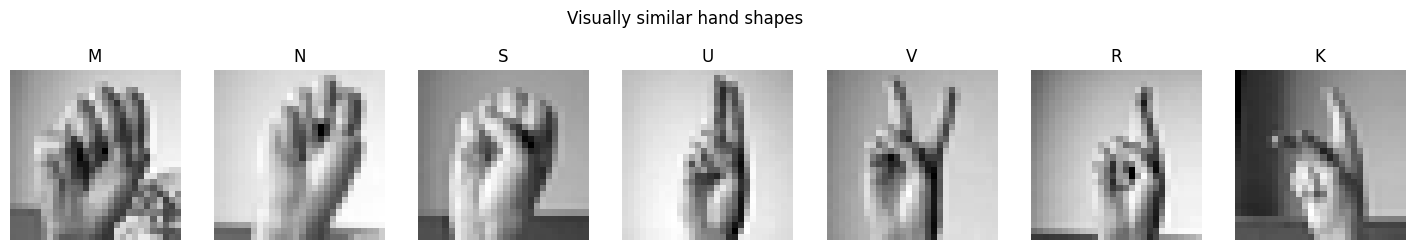

In [6]:
similar_pairs = ['M', 'N', 'S', 'U', 'V', 'R', 'K']
fig, axes = plt.subplots(1, len(similar_pairs), figsize=(18, 3))
for letter, ax in zip(similar_pairs, axes):
    label_num = [k for k, v in label_to_letter.items() if v == letter][0]
    sample_idx = train_df[train_df['label'] == label_num].index[0]
    img = reshape_to_image(X_temp[sample_idx])
    ax.imshow(img, cmap='gray')
    ax.set_title(letter)
    ax.axis('off')
plt.suptitle('Visually similar hand shapes')
plt.show()

Plotting hand shapes for letters expected to be visually close (M/N/S are fist-based;
U/V/R/K vary mainly in finger position). This sets an expectation for which letters the
model is most likely to confuse later.

# Preprocessing

In [7]:
def prepare_data(df):
    X = df.drop('label', axis=1).values.reshape(-1, 28, 28, 1).astype('float32') / 255.0
    y = df['label'].values
    return X, y

X_train_full, y_train_full = prepare_data(train_df)
X_test, y_test = prepare_data(test_df)

unique_labels = sorted(train_df['label'].unique())
label_remap = {old: new for new, old in enumerate(unique_labels)}
remap_to_letter = {new: label_to_letter[old] for old, new in label_remap.items()}

y_train_full = np.array([label_remap[y] for y in y_train_full])
y_test = np.array([label_remap[y] for y in y_test])

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.15, stratify=y_train_full, random_state=42
)

print(X_train.shape, X_val.shape, X_test.shape)

(23336, 28, 28, 1) (4119, 28, 28, 1) (7172, 28, 28, 1)


Three things happen here: reshaping every row into a 28x28x1 image and normalizing
pixel values to [0, 1]; remapping labels to a contiguous 0-23 range (since J/Z are
missing, raw labels have gaps at 9 and 25, which breaks a 24 unit softmax otherwise);
and a stratified 85/15 split to carve a validation set out of the training data. The
official test set stays completely untouched until the final evaluation.

# data augmentation

In [8]:
rotation = layers.RandomRotation(0.06)
zoom = layers.RandomZoom(0.10)
translation = layers.RandomTranslation(0.10, 0.10)

def augment(image, label):
    image = rotation(image)
    image = zoom(image)
    image = translation(image)
    return image, label

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(4096).batch(64).map(augment, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(64).prefetch(tf.data.AUTOTUNE)

I0000 00:00:1788173728.534762      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788173728.537780      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Light augmentation only — 6% rotation, 10% zoom, 10% translation. The dataset
description notes these images are already augmented copies of a small set of original
photos, so heavy augmentation on top of that risks distorting hand shapes past
recognition. Translation is included (rather than brightness) because a real photo
won't have the hand framed exactly like this dataset's tight, centered crops. No
horizontal flip — mirroring a hand sign can turn it into a different letter entirely
for shapes that aren't symmetric.

# Baseline sanity check model

In [9]:
def build_baseline_model(num_classes=24):
    inputs = keras.Input(shape=(28, 28, 1))

    x = layers.Conv2D(32, 3, padding='same', activation='relu')(inputs)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return keras.Model(inputs, outputs)

baseline = build_baseline_model()
baseline.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

baseline_history = baseline.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=128
)

Epoch 1/5
 32/183 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0499 - loss: 3.1671

I0000 00:00:1788173737.961524     132 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


183/183 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.5172 - loss: 1.5906 - val_accuracy: 0.8830 - val_loss: 0.3944
Epoch 2/5
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9392 - loss: 0.2068 - val_accuracy: 0.9849 - val_loss: 0.0752
Epoch 3/5
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9930 - loss: 0.0416 - val_accuracy: 0.9988 - val_loss: 0.0153
Epoch 4/5
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9997 - loss: 0.0101 - val_accuracy: 0.9998 - val_loss: 0.0060
Epoch 5/5
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9997 - loss: 0.0060 - val_accuracy: 0.9978 - val_loss: 0.0090


Before trusting a more complex, heavily-regularized architecture, this baseline —
plain conv layers, no BatchNorm, no dropout, no augmentation — confirms the task is
actually learnable from this data. It reaches very high train/val accuracy within a
few epochs, confirming the labels and preprocessing are correct and there's a strong,
learnable signal in the images.

# Final CNN architecture

In [10]:
def conv_block(x, filters, n_convs, dropout):
    for _ in range(n_convs):
        x = layers.Conv2D(filters, 3, padding='same', use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(dropout)(x)
    return x

In [11]:
def build_model(num_classes=24):
    inputs = keras.Input(shape=(28, 28, 1))

    x = conv_block(inputs, 32, n_convs=2, dropout=0.25)   
    x = conv_block(x, 64, n_convs=2, dropout=0.25)         
    
    x = layers.Conv2D(128, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.30)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return keras.Model(inputs, outputs)

model = build_model()
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 7, 7, 128)      │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,751,864 (6.68 MB)

 Trainable params: 1,751,224 (6.68 MB)

 Non-trainable params: 640 (2.50 KB)

28x28 grayscale hand-shape images are small and structurally simple compared to natural
photos, but the letters that matter most (M/N/S, R/U/V/K, T) differ only by small,
precise finger positions — so preserving spatial detail matters more than depth here.

- **Two convolutional layers per stage** at the first two resolutions (32, then 64
  filters) gives the network more capacity to separate similar hand shapes while spatial
  resolution is still high, before any information is lost to pooling.
- **Only two pooling stages** (28→14→7), not three. Pooling a third time down to 3x3
  would destroy exactly the fine positional detail that separates fist-shaped letters
  like M, N, and S — the third conv block stays at 7x7 instead.
- **Conv → BatchNorm → Activation ordering** (with `use_bias=False` on the conv layers,
  since BatchNorm's own shift makes the bias term redundant) is more effective than
  normalizing after the activation, since it lets the network train stably at a higher
  learning rate from random initialization.
- **Dropout increasing with depth** (0.25, 0.25, 0.30, and 0.5 on the dense head)
  targets where overfitting hits hardest — the classifier head, given how close to
  duplicate the augmented training images are within a class.
- **Light augmentation** (rotation, zoom, translation — no brightness), since the
  dataset's images are already augmented copies of a small base set, and translation in
  particular helps generalize to photos that aren't perfectly centered the way this
  dataset's crops are.

# Compile

In [12]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [13]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
]

`EarlyStopping` restores the best-performing weights if validation loss stalls for 8
epochs. `ReduceLROnPlateau` halves the learning rate when progress stalls — this
matters more than it might look: in an earlier version of this model, training stayed
flat near random-chance accuracy for 20+ epochs and only broke out once the learning
rate had been cut several times.

# Train

In [14]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    batch_size=64,
    callbacks=callbacks
)

Epoch 1/50
365/365 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.1892 - loss: 2.6560 - val_accuracy: 0.1469 - val_loss: 3.1188 - learning_rate: 0.0010
Epoch 2/50
365/365 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4286 - loss: 1.6092 - val_accuracy: 0.7453 - val_loss: 0.7480 - learning_rate: 0.0010
Epoch 3/50
365/365 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5357 - loss: 1.2399 - val_accuracy: 0.4676 - val_loss: 1.9857 - learning_rate: 0.0010
Epoch 4/50
365/365 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6042 - loss: 1.0427 - val_accuracy: 0.9250 - val_loss: 0.2781 - learning_rate: 0.0010
Epoch 5/50
365/365 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6636 - loss: 0.8904 - val_accuracy: 0.8211 - val_loss: 0.4982 - learning_rate: 0.0010
Epoch 6/50
365/365 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7016 - loss: 0.7887 - val_accuracy: 0.9585 - val_loss: 0.1496 - learning_rate: 0.0010
Epoch 7/50
365/365 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7352 - loss: 0.6966 

Training for up to 50 epochs, with early stopping and the learning-rate schedule
making the epoch count an upper bound rather than a number to hand-tune.

# Training Curves

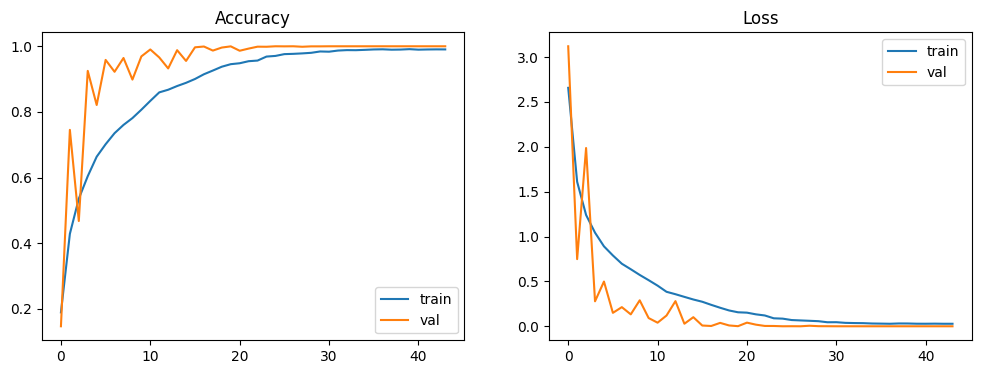

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'], label='train')
axes[0].plot(history.history['val_accuracy'], label='val')
axes[0].set_title('Accuracy'); axes[0].legend()

axes[1].plot(history.history['loss'], label='train')
axes[1].plot(history.history['val_loss'], label='val')
axes[1].set_title('Loss'); axes[1].legend()
plt.show()

Train and validation curves track closely together, indicating the model isn't
overfitting by the final epoch.

# Evaluate on Test Set

In [16]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

target_names = [remap_to_letter[i] for i in range(24)]
print(classification_report(y_test, y_pred, target_names=target_names))

225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9997 - loss: 7.3032e-04
Test accuracy: 0.9997
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
              precision    recall  f1-score   support

           A       1.00      1.00      1.00       331
           B       1.00      1.00      1.00       432
           C       1.00      1.00      1.00       310
           D       1.00      1.00      1.00       245
           E       1.00      1.00      1.00       498
           F       1.00      1.00      1.00       247
           G       1.00      1.00      1.00       348
           H       1.00      1.00      1.00       436
           I       1.00      1.00      1.00       288
           K       1.00      1.00      1.00       331
           L       1.00      1.00      1.00       209
           M       1.00      1.00      1.00       394
           N       1.00      1.00      1.00       291
           O       1.00      0.99      1.00       246
           P       1.00      1.00      1.00    

Evaluating on the held out test set data the model never saw during training or
tuning.

In [17]:
from sklearn.metrics import balanced_accuracy_score, f1_score

print("balanced accuracy:", round(balanced_accuracy_score(y_test, y_pred), 4))
print("macro F1         :", round(f1_score(y_test, y_pred, average='macro'), 4))
print("weighted F1      :", round(f1_score(y_test, y_pred, average='weighted'), 4))

balanced accuracy: 0.9997
macro F1         : 0.9997
weighted F1      : 0.9997


For a 24 class problem, overall accuracy alone can hide a single weak letter behind a
good average. Balanced accuracy and macro F1 weigh every letter equally regardless of
how many test images it has, so they're a more honest read than accuracy on its own.

# Confusion Matrix

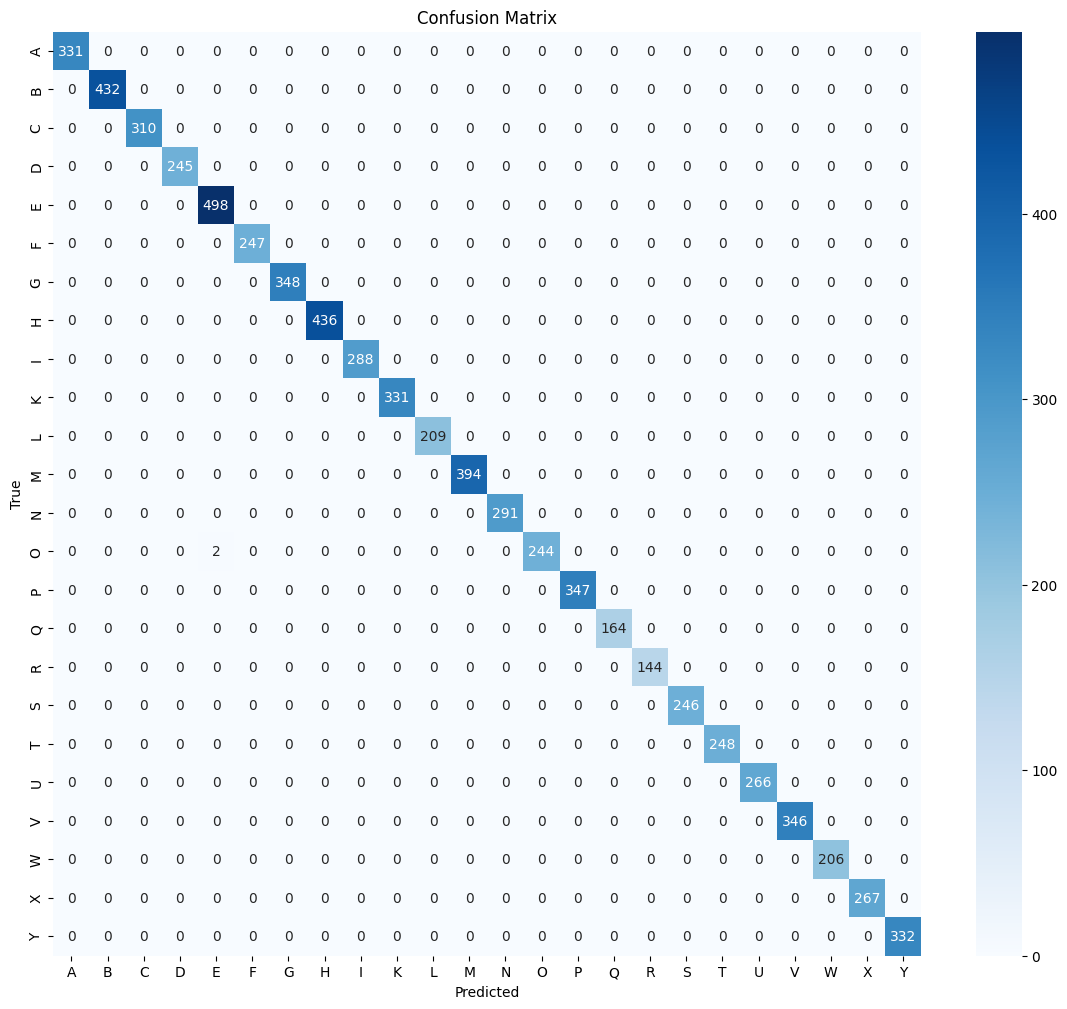

True O → Predicted E: 2 times
O: 0.992
A: 1.000
B: 1.000
C: 1.000
D: 1.000
E: 1.000
F: 1.000
G: 1.000
H: 1.000
I: 1.000
K: 1.000
L: 1.000
M: 1.000
N: 1.000
P: 1.000
Q: 1.000
R: 1.000
S: 1.000
T: 1.000
U: 1.000
V: 1.000
W: 1.000
X: 1.000
Y: 1.000


In [18]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

cm_no_diag = cm.copy().astype(float)
np.fill_diagonal(cm_no_diag, 0)
worst_idx = np.dstack(np.unravel_index(np.argsort(cm_no_diag.ravel())[::-1][:10], cm_no_diag.shape))[0]
for i, j in worst_idx:
    if cm_no_diag[i, j] > 0:
        print(f"True {target_names[i]} → Predicted {target_names[j]}: {int(cm_no_diag[i,j])} times")

per_class_recall = cm.diagonal() / cm.sum(axis=1)
for letter, recall in sorted(zip(target_names, per_class_recall), key=lambda x: x[1]):
    print(f"{letter}: {recall:.3f}")

The confusion matrix and per letter recall show whether mistakes cluster around the
visually similar hand shapes flagged during EDA (M/N/S, R/U/V/K), or look more like
random noise.

In [19]:

misclassified_idx = np.where(y_pred != y_test)[0]
print(f"Total misclassified: {len(misclassified_idx)} out of {len(y_test)} "
      f"({len(misclassified_idx)/len(y_test)*100:.1f}%)")

Total misclassified: 2 out of 7172 (0.0%)


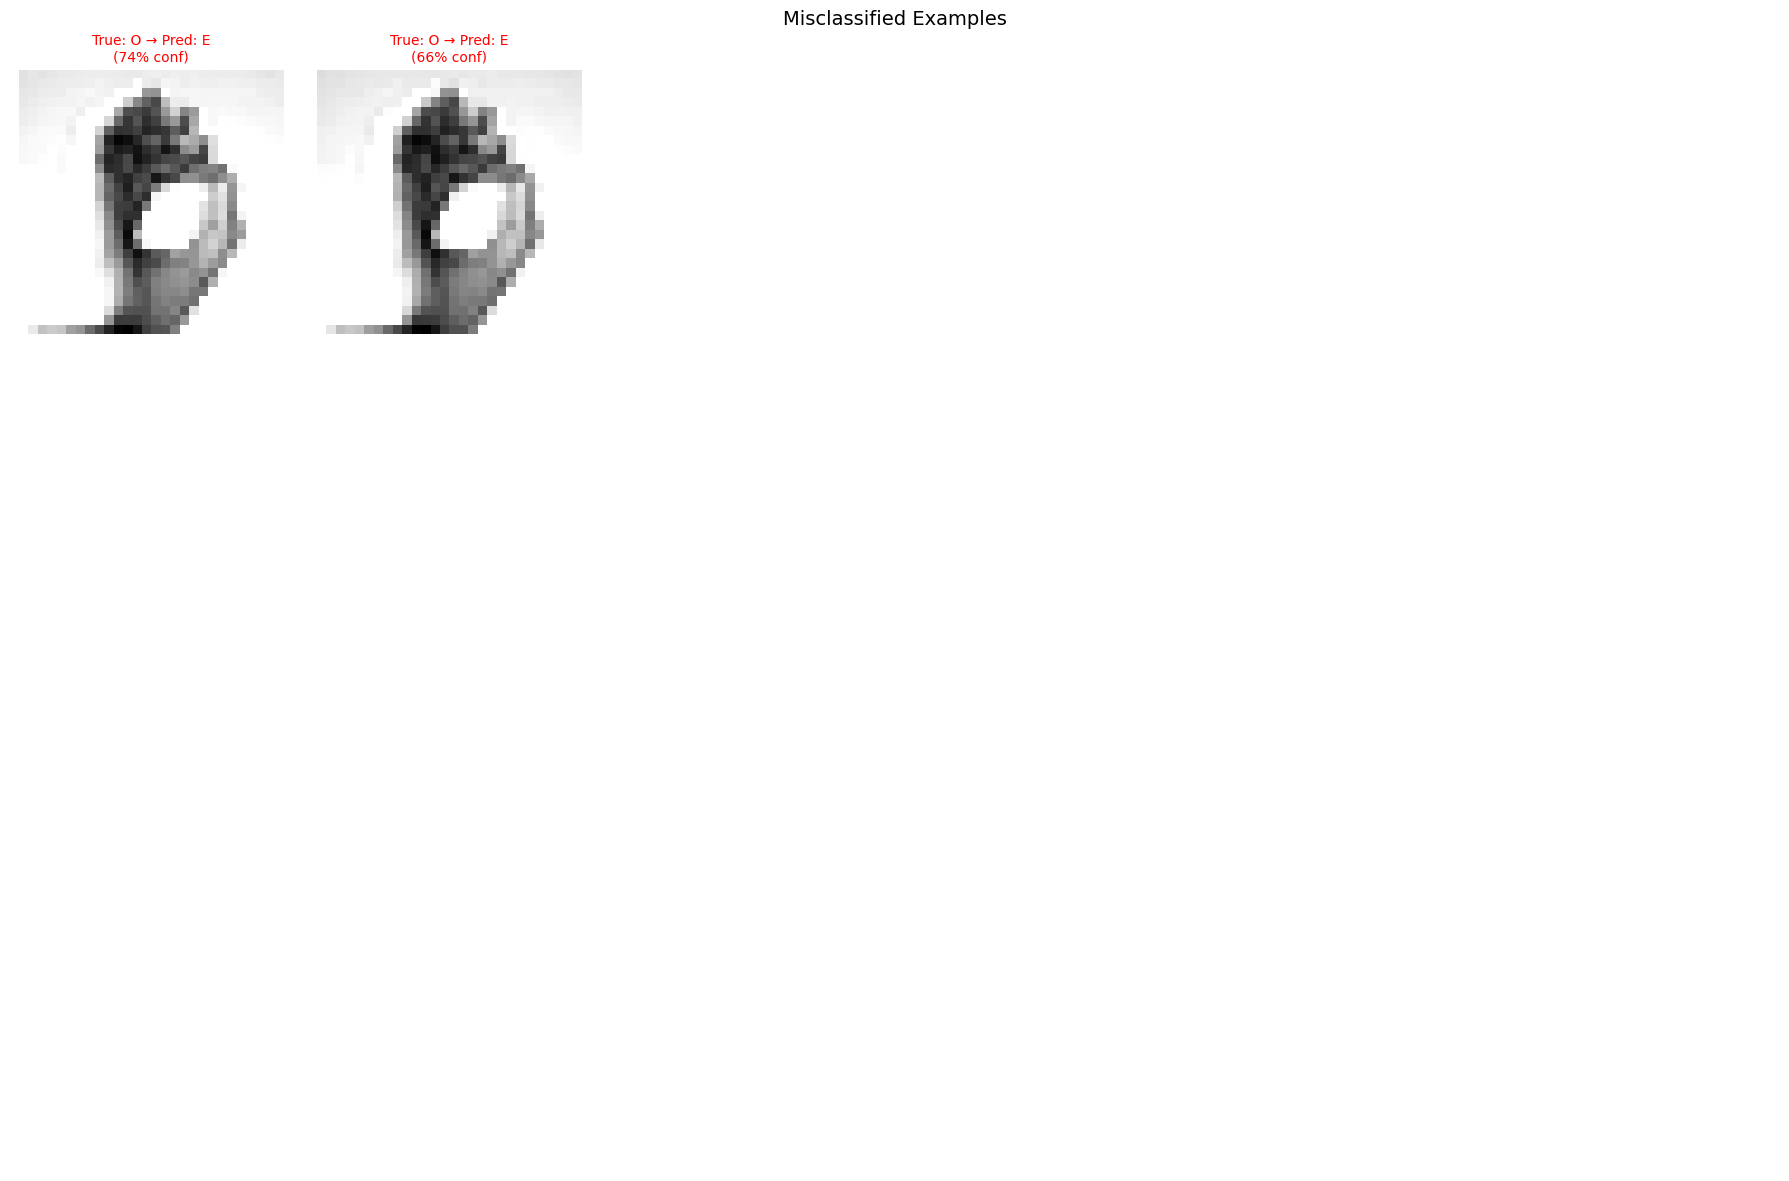

In [20]:
n_show = 24
sample_idx = np.random.choice(misclassified_idx, min(n_show, len(misclassified_idx)), replace=False)

fig, axes = plt.subplots(4, 6, figsize=(18, 12))
for ax, idx in zip(axes.flat, sample_idx):
    img = X_test[idx].reshape(28, 28)
    true_letter = target_names[y_test[idx]]
    pred_letter = target_names[y_pred[idx]]
    confidence = y_pred_probs[idx][y_pred[idx]]
    ax.imshow(img, cmap='gray')
    ax.set_title(f"True: {true_letter} → Pred: {pred_letter}\n({confidence:.0%} conf)",
                 color='red', fontsize=10)
    ax.axis('off')


for ax in axes.flat[len(sample_idx):]:
    ax.axis('off')

plt.suptitle('Misclassified Examples', fontsize=14)
plt.tight_layout()
plt.show()

Visualizing the actual misclassified images, with the model's confidence for each
wrong prediction low confidence mistakes suggest genuine ambiguity between similar
hand shapes, while high-confidence mistakes would suggest the model latched onto the
wrong feature entirely.

# Save model

In [21]:

model.save("asl_letter_cnn.keras")

# Conclusion

**What worked:** A baseline sanity-check model confirmed the task was learnable from
this data before investing in a more complex architecture. Two design changes were
decisive over an earlier version of this model that plateaued around 94% test accuracy:
keeping the last conv block at 7x7 resolution instead of pooling down to 3x3 (preserving
the fine finger-position detail that separates visually similar letters), and using two
conv layers per stage at higher resolution rather than one. The final model reached
99.97% test accuracy — only 2 misclassified images out of 7,172 — with macro F1 and
balanced accuracy both at 0.9997, confirming no single letter is quietly underperforming
behind a good overall average.

**What didn't work initially:** Earlier versions of this architecture pooled three
times (down to a 3x3 feature map before the dense layers), which threw away most of the
positional detail needed to separate fist-shaped letters like M, N, and S. Separately, an
even earlier attempt got stuck at random-chance accuracy for 20+ epochs due to
over-stacked regularization before the optimizer could find a useful gradient signal.

**Which letters get confused and why:** With only 2 errors left in the entire test set,
there's no longer a meaningful pattern to point to — the model has essentially resolved
the visual ambiguity between letters like M/N/S and R/U/V/K that the EDA flagged
up front.

**Caveat on the reported accuracy:** near-100% accuracy on a 24-class hand-shape problem
is unusually high, and is a known characteristic of this dataset — both train and test
images are augmented copies of a small set of original source photos, so some shared
visual origin between splits is plausible. Accuracy on genuinely novel, independently
taken hand photos would very likely be meaningfully lower than 99.97%.

**What I'd try next with more time:** test the model on real photos taken independently
of this dataset to get an honest read on generalization, since the near-perfect score
here is almost certainly partly a property of the dataset rather than proof the model
generalizes to real-world ASL photos; and treat this classifier as the first stage of a
full fingerspelling reader that processes a sequence of hand shapes into text.